In [1]:
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
setwd("/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/")
output_path <- "./stat_output/S6"
create_path(output_path)
fread_c("./stat_output/S1/sample_metadata_ordered.txt") -> sample_metadata
# 去掉PCP第4个重复
sample_metadata %>% filter(Replicate!=4) -> sample_metadata
psm_sep_all_path <- '/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/stat_output/S6/psm_sep_all.txt'
fread_c(psm_sep_all_path) -> psm_sep_all
psm_sep_all %>% filter(PSM_type=="Unique") -> psm_sep_unique
# 去掉PCP第4个重复
psm_sep_unique %>% filter(!grepl("4_PCP",psm_sep_unique$Sample)) -> psm_sep_unique
psm_sep_unique %>% distinct(Protein,Sample) -> all_sample_sep
all_sample_sep %>% merge(sample_metadata,by = "Sample") -> all_sample_sep_m_meta
all_sample_sep_m_meta %>% arrange(Enrichment,Eyzyme,Replicate) -> all_sample_sep_m_meta

Warning message:
“程辑包‘stringr’是用R版本4.3.2 来建造的”


# 加上注释的小肽

In [1]:
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")
source("~/bin/lit_utils.R")
lib_text()
lib_plot()

Warning message:
“程辑包‘stringr’是用R版本4.3.2 来建造的”


In [2]:
setwd("/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/")
output_path <- "./stat_output/S6"
create_path(output_path)

In [3]:
fread_c("./stat_output/S1/sample_metadata_ordered.txt") -> sample_metadata
# 去掉PCP第4个重复
sample_metadata %>% filter(Replicate!=4) -> sample_metadata

In [4]:
psm_sep_all_path <- '/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/stat_output/S6/psm_sep_all.txt'

In [5]:
fread_c(psm_sep_all_path) -> psm_sep_all

In [6]:
psm_sep_all %>% filter(PSM_type=="Unique") -> psm_sep_unique

In [7]:
# 去掉PCP第4个重复
psm_sep_unique %>% filter(!grepl("4_PCP",psm_sep_unique$Sample)) -> psm_sep_unique

In [8]:
psm_sep_unique %>% filter(grepl("^ENS",Protein)) %>% count(Protein)

Protein,n
<chr>,<int>
ENST00000005340.10-chr17:7225351-7225558,1
ENST00000064778.8-chr11:73407530-73409496,1
ENST00000168216.11-chrX:53431403-53431813,1
ENST00000199940.10+chr2:209730325-209730397,35
ENST00000215375.7+chr19:1241961-1244437,30
ENST00000216019.11-chr22:38485934-38485997,2
ENST00000216019.11-chr22:38485934-38486048,3
ENST00000216121.12-chr22:29555934-29561547,1
ENST00000216129.7-chr22:43168007-43171851,3


[1] "Sample"     "Protein"    "Eyzyme"     "Period"     "Enrichment"
[6] "Replicate"  "ms2_count"

png 
  2

png 
  2

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


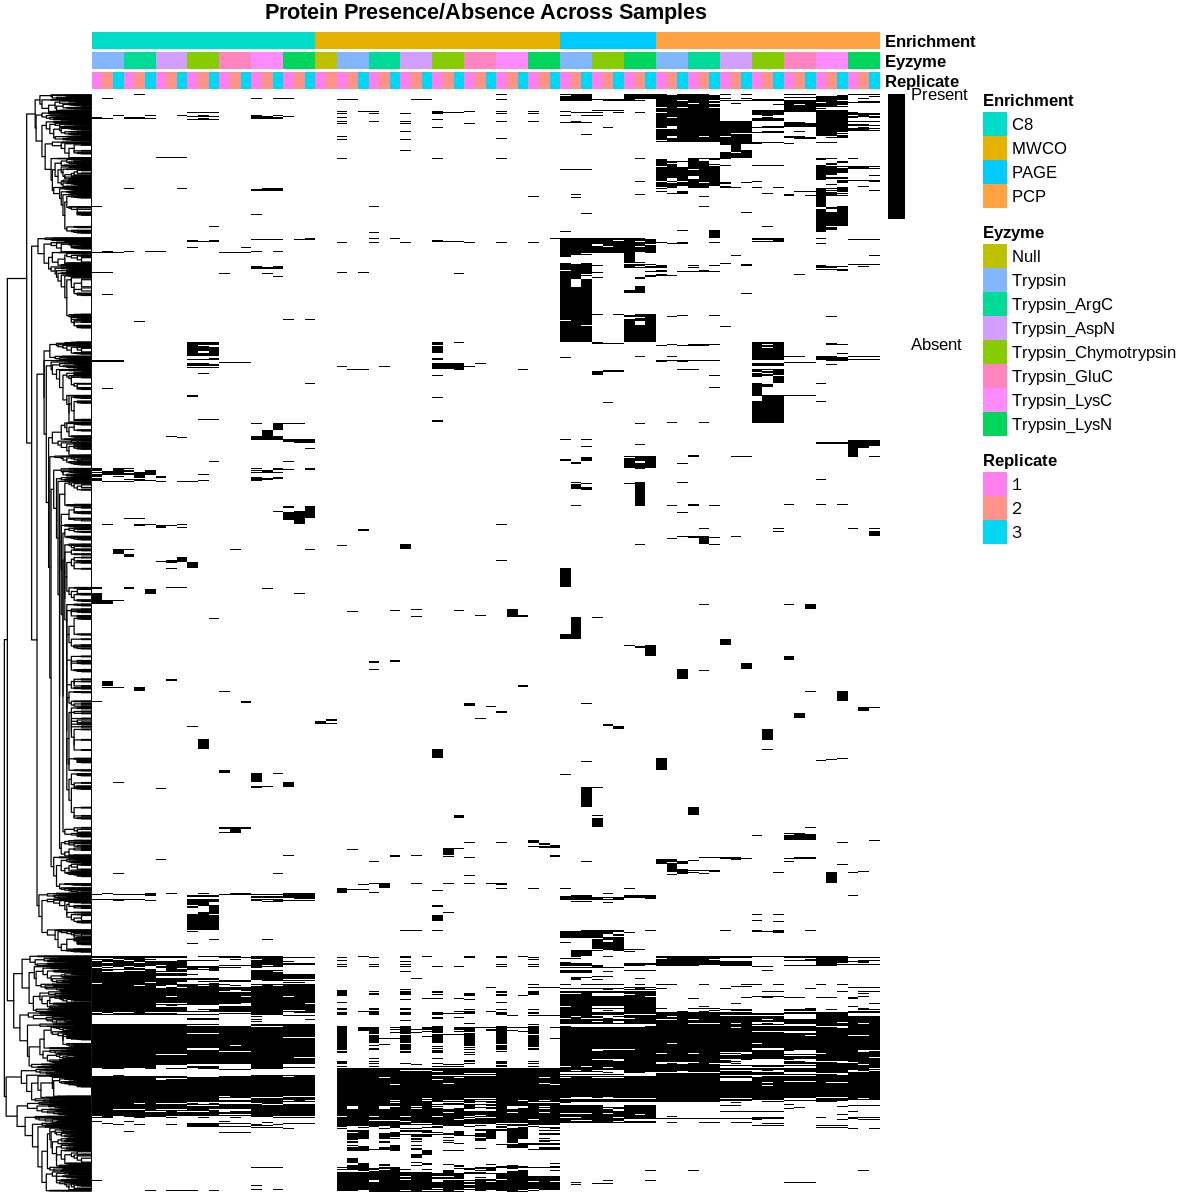

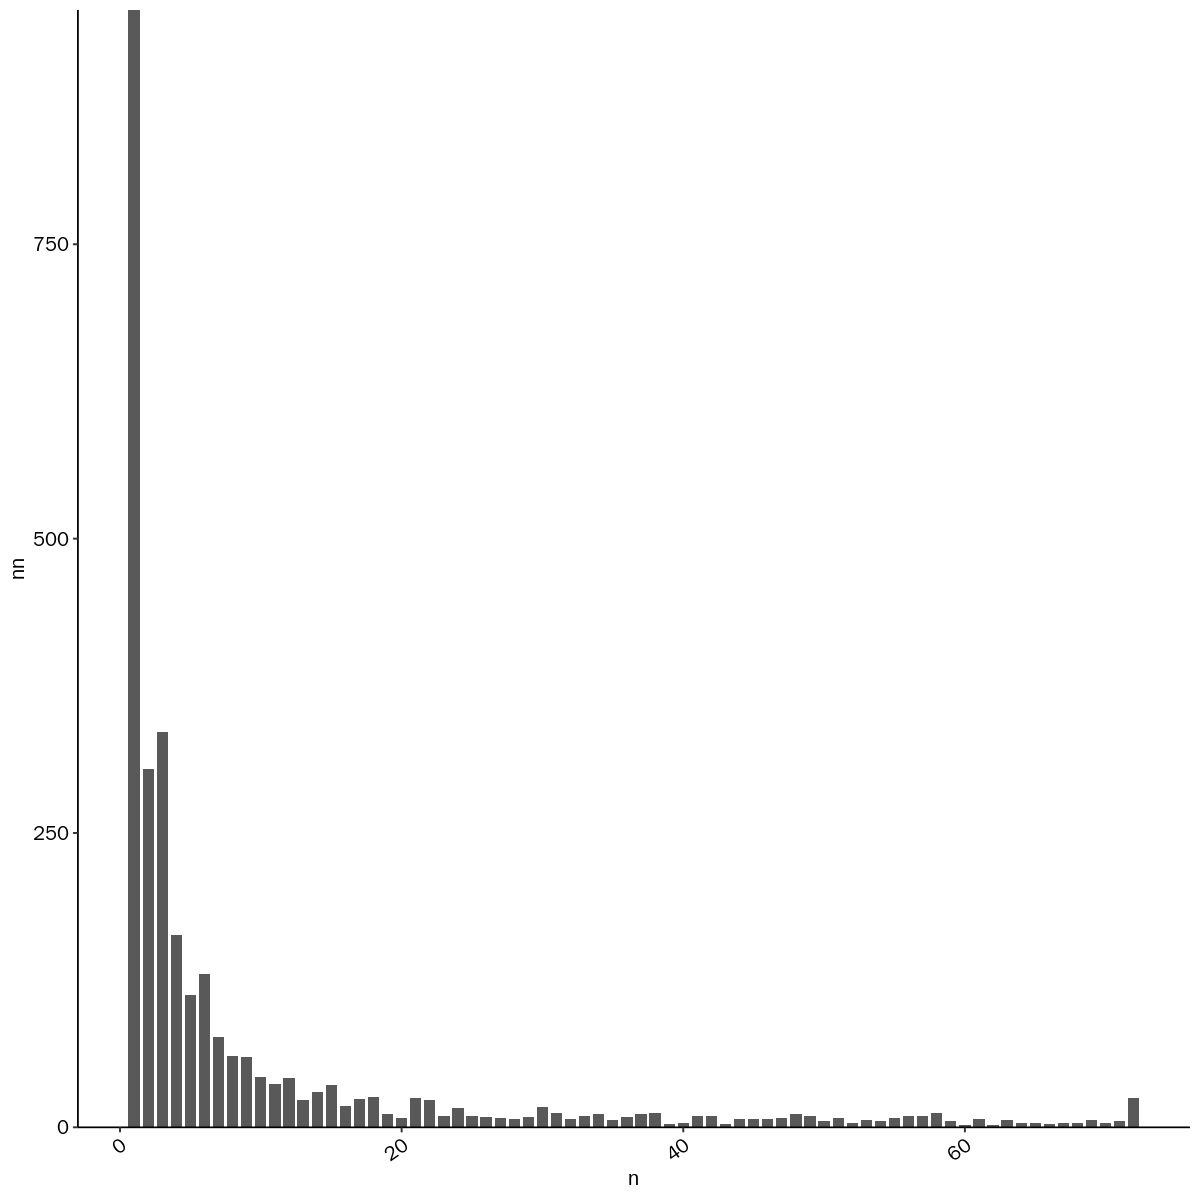

In [132]:
##### 2. Plot #####
##### 2.0 不同酶切方法以及富集方法鉴定到的小肽数量 #####
library(ggplot2)
psm_sep_unique %>% distinct(Sample,Protein,.keep_all = T) -> df_1
df_1 %>% group_by(Sample) %>% summarise(count = n(), .groups = 'drop') %>% merge(sample_metadata,by="Sample") -> df_2
ggplot(df_2, aes(x = Enrichment, y = count, fill = Eyzyme)) +
  geom_boxplot(position = position_dodge(0.8), width = 0.7, alpha = 0.7) +
  stat_summary(
    fun = mean, geom = "point", shape = 18, size = 3, color = "red",
    position = position_dodge(0.8), show.legend = FALSE
  ) +
  labs(x = "Enrichment",
       y = "Identified SEP number",
       fill = "Eyzyme") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") -> p
ggsave(p,filename=o("enrichmen_enzyme_identified_sep_number.pdf"),width = 8,height = 5)
##### 2.1 Saturation Plot #####
set.seed(123)
# sample_order <- sample(sample_metadata$Sample)
sample_order <- sample_metadata %>% arrange(Enrichment,Eyzyme,Replicate) %>% .$Sample
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = psm_sep_unique,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
ggsave("protein_cumulative_combo.pdf", width = 10, height = 5)
ggsave(res_protein$version_sampleNum,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 18)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 18)

# 2. 肽段累积分析（带柱状图）
res_peptide <- cumu_combo_plot(
  df = psm_sep_unique,
  sample_order = sample_order,
  target_col = "Peptide",
  show_bar = TRUE
)
ggsave(res_peptide$version_sampleNum,filename=o("cumu_pep_sample_n.pdf"),height = 5,width = 18)
ggsave(res_peptide$version_sampleName,filename=o("cumu_pep_sample_name.pdf"),height = 5,width = 18)

##### 2.2 Overlap between different methods #####
psm_sep_unique %>% distinct(Protein,Sample) -> all_sample_sep
all_sample_sep %>% merge(sample_metadata,by = "Sample") -> all_sample_sep_m_meta
colnames(all_sample_sep_m_meta)
##### 2.2.1 Compare enzyme #####
compare_enzyme <- function(method){
  all_sample_sep_m_meta %>% filter(Enrichment==method) %>% filter(Eyzyme!="Null") -> df
  split(df[, "Protein"], df$Eyzyme) -> split_df
  venn_plot_n(split_df) -> p
  path <- paste0("eyzyme_compare_",method,".pdf")
  ggsave(p,filename=o(path),width = 8,height = 5)
  return(p)
}
lapply(c("MWCO","PAGE","C8","PCP"), compare_enzyme) -> l
##### 2.2.2 Compare enrichment method #####
compare_method <- function(enzyme){
  all_sample_sep_m_meta %>% filter(Eyzyme==enzyme) -> df
  split(df[, "Protein"], df$Enrichment) -> split_df
  venn_plot_n(split_df) -> p
  path <- paste0("method_compare_",enzyme,".pdf")
  ggsave(p,filename=o(path),width = 8,height = 5)
  return(p)
}
lapply(c("Trypsin","Trypsin_LysN","Trypsin_Chymotrypsin"), compare_method) -> l

##### 2.2.3 Compare different replicates #####
split(all_sample_sep_m_meta[, "Protein"], all_sample_sep_m_meta$Replicate) -> split_df
venn_plot_n(split_df)->p
ggsave(p,filename=o("replicate_compare.pdf"),width = 8,height = 5)

##### 2.2.4 绘制一个比较大的热图 #####

# Assuming your data is in a dataframe called all_sample_sep_m_meta

# First, create a binary matrix of protein presence (1) vs absence (0)
library(pheatmap)

all_sample_sep_m_meta %>% arrange(Enrichment,Eyzyme,Replicate) -> all_sample_sep_m_meta

# Create a presence/absence matrix
binary_matrix <- all_sample_sep_m_meta %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()

# Create annotation data for columns (samples)
sample_annot <- all_sample_sep_m_meta %>%
  select(Sample,Replicate, Eyzyme,Enrichment) %>%
  distinct() %>%
  mutate(Replicate = as.factor(Replicate)) %>%
  column_to_rownames("Sample")

# Create the heatmap
pheatmap::pheatmap(binary_matrix,
         cluster_cols = FALSE,  # Cluster samples
         cluster_rows = TRUE,  # Cluster proteins
         color = c("white", "black"),  # 0 = white, 1 = black
         legend_breaks = c(0, 1),
         legend_labels = c("Absent", "Present"),
         annotation_col = sample_annot,
         show_rownames = FALSE,  # Typically too many proteins to show all names
         show_colnames = FALSE,  # Typically too many proteins to show all names
         main = "Protein Presence/Absence Across Samples") -> p

ggsave(p,filename=o("protein_sample_detection_heatmap.pdf"),width = 8,height = 8)

##### 2.2.4.1 绘制一个比较大的热图，但是使用complexheatmap #####
library(ComplexHeatmap)
library(circlize)

all_sample_sep_m_meta %>% arrange(Enrichment,Eyzyme,Replicate) -> all_sample_sep_m_meta

# Assuming your data is in a dataframe called all_sample_sep_m_meta
# Create a binary detection matrix
binary_matrix <- all_sample_sep_m_meta %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()

# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- all_sample_sep_m_meta %>%
  select(Sample,Enrichment,Eyzyme,Replicate) %>%
  distinct() %>%
  mutate(Replicate = as.factor(Replicate)) %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
replicate_colors <- setNames(brewer.pal(length(unique(sample_annot$Replicate)), "Set3"), 
                             unique(sample_annot$Replicate))

# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors,
    Replicate = replicate_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)

# Create the heatmap
ht <- Heatmap(
  binary_matrix,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = TRUE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)

ht_1 <- Heatmap(
  binary_matrix,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)

# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap.pdf"), width = 12, height = 8)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht)
# 3. 关闭设备，保存文件
dev.off()

# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap_no_cluster_cols.pdf"), width = 12, height = 8)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht_1)
# 3. 关闭设备，保存文件
dev.off()

##### 2.2.5 不同测定鉴定到的次数 #####
all_sample_sep_m_meta %>% count(Protein) %>% count(n) %>% bar_plot_stated("n","nn")


# 经典小肽

In [13]:
all_sample_sep_m_meta %>% filter(grepl("^sp",Protein)) -> all_sample_sep_m_meta_cano
all_sample_sep_m_meta_cano -> df
# Assuming your data is in a dataframe called all_sample_sep_m_meta
# Create a binary detection matrix
binary_matrix <- df %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()

# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Eyzyme,Replicate) %>%
  distinct() %>%
  mutate(Replicate = as.factor(Replicate)) %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
replicate_colors <- setNames(brewer.pal(length(unique(sample_annot$Replicate)), "Set3"), 
                             unique(sample_annot$Replicate))

# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors,
    Replicate = replicate_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)


ht_1 <- Heatmap(
  binary_matrix,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)

# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap_no_cluster_cols_cano.pdf"), width = 12, height = 8)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht_1)
# 3. 关闭设备，保存文件
dev.off()


png 
  2

In [14]:
nrow(binary_matrix)

[1] 819

# 合并不同的重复

In [15]:
# 查看蛋白在一种富集方法一种酶切方法中重复被检测到的次数
count(all_sample_sep_m_meta_cano,Protein,Eyzyme,Enrichment) %>% 
group_by(Eyzyme,Enrichment) %>% 
count(n) -> df

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


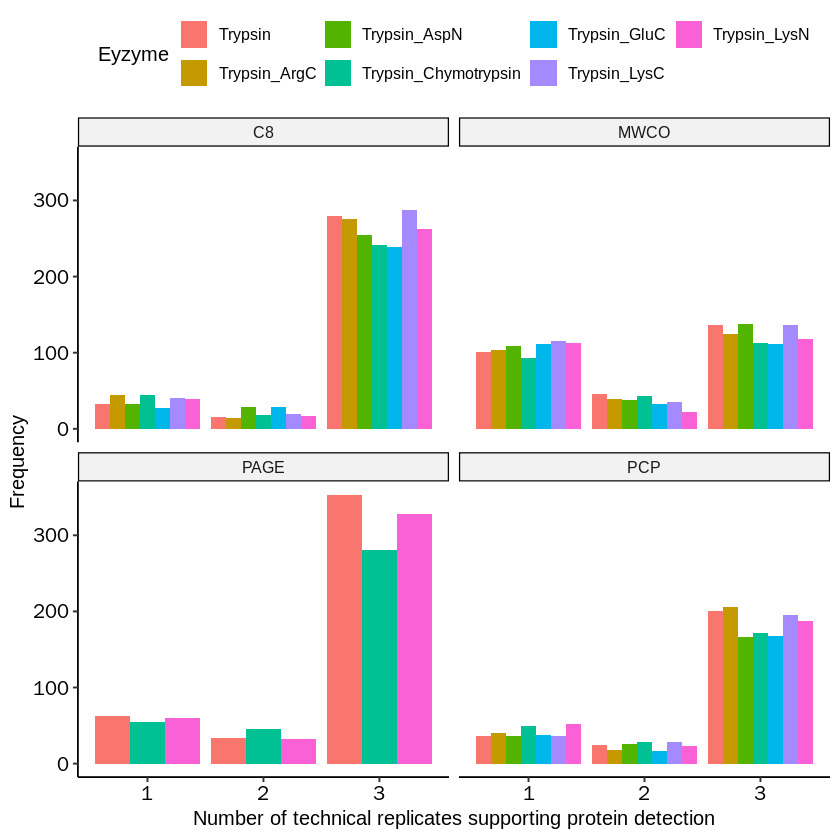

In [16]:
library(ggplot2)
ggplot(df, aes(x=factor(n), y=nn, fill=Eyzyme)) +
geom_bar(stat='identity', position='dodge') +
facet_wrap(~Enrichment) +
labs(x='Number of technical replicates supporting protein detection', y='Frequency')+
theme_3()

In [17]:
# 70%的蛋白质测定被3个技术重复支持
df %>% group_by(n) %>% summarise(sum_nn=sum(nn)) -> df_all
df_all$sum_nn/sum(df_all$sum_nn)

[1] 0.20651869 0.09468952 0.69879180

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


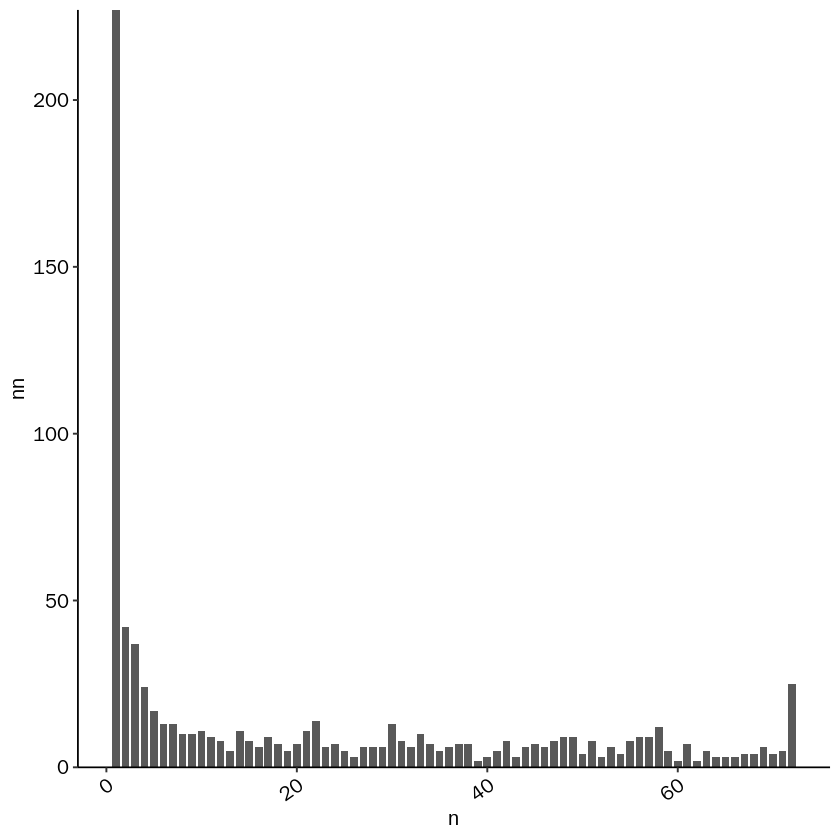

In [18]:
all_sample_sep_m_meta_cano %>% count(Protein) %>% count(n) %>% bar_plot_stated("n","nn")

In [19]:
all_sample_sep_m_meta_cano %>% count(Protein) %>% count(n) -> df
df$nn/sum(df$nn) -> freq
# 72%蛋白质的被2次以上的测定所支持
1-freq[1]

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


[1] 0.7228327

In [20]:
# 合并重复
all_sample_sep_m_meta_cano$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", all_sample_sep_m_meta_cano$Sample)
head(all_sample_sep_m_meta_cano)

,Sample,Protein,Eyzyme,Period,Enrichment,Replicate,ms2_count,Sample_merge_replicate
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,21pcw_1_C8_T_T,sp|P60468|SC61B_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T
2,21pcw_1_C8_T_T,sp|P02656|APOC3_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T
3,21pcw_1_C8_T_T,sp|P52435|RPB11_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T
4,21pcw_1_C8_T_T,sp|Q96DA6|TIM14_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T
5,21pcw_1_C8_T_T,sp|P27816-7|MAP4_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T
6,21pcw_1_C8_T_T,sp|Q9H492|MLP3A_HUMAN,Trypsin,21pcw,C8,1,117437,21pcw_C8_T_T


In [21]:
distinct(all_sample_sep_m_meta_cano,Protein,Sample_merge_replicate,Eyzyme,Enrichment) -> all_sample_sep_m_meta_cano_1

In [22]:
head(all_sample_sep_m_meta_cano_1)
all_sample_sep_m_meta_cano_1 %>% rename(Sample=Sample_merge_replicate) -> all_sample_sep_m_meta_cano_1

,Protein,Sample_merge_replicate,Eyzyme,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,sp|P60468|SC61B_HUMAN,21pcw_C8_T_T,Trypsin,C8
2,sp|P02656|APOC3_HUMAN,21pcw_C8_T_T,Trypsin,C8
3,sp|P52435|RPB11_HUMAN,21pcw_C8_T_T,Trypsin,C8
4,sp|Q96DA6|TIM14_HUMAN,21pcw_C8_T_T,Trypsin,C8
5,sp|P27816-7|MAP4_HUMAN,21pcw_C8_T_T,Trypsin,C8
6,sp|Q9H492|MLP3A_HUMAN,21pcw_C8_T_T,Trypsin,C8


png 
  2

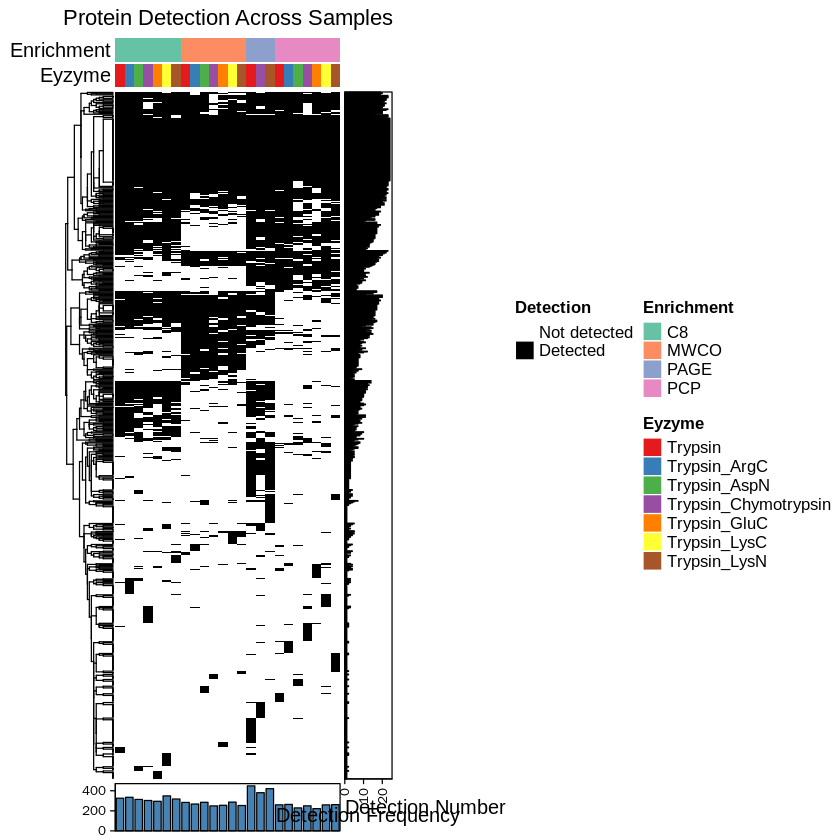

In [23]:
df <- all_sample_sep_m_meta_cano_1
# Assuming your data is in a dataframe called all_sample_sep_m_meta
# Create a binary detection matrix
binary_matrix <- df %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()

# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Eyzyme) %>%
  distinct() %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)


ht_1 <- Heatmap(
  binary_matrix,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)


ht_1


# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap_no_cluster_cols_cano_merge_replicate.pdf"), width = 12, height = 8)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht_1)
# 3. 关闭设备，保存文件
dev.off()

In [180]:
para_1 <- c("binary", "euclidean")  # 二进制友好方法
para_2 <- c("complete", "average")  # ward.D可能不适合非欧式距离

In [186]:
library(ComplexHeatmap)
library(gridExtra)
library(cowplot)

# 创建空列表存储热图的 grob 对象
grob_list <- list()

# 遍历所有参数组合
for (dist in para_1) {
  for (method in para_2) {
    # 创建当前参数组合的热图
 ht <- Heatmap(
  binary_matrix,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
     clustering_distance_rows=dist,
     clustering_method_rows=method,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
     column_title = paste("Dist:", dist, "| Method:", method), # 每个子图显示参数
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)  
# 将热图转换为 grob 并存储
grob_list[[length(grob_list) + 1]] <- grid.grabExpr(draw(ht))
  }
}


png 
  2

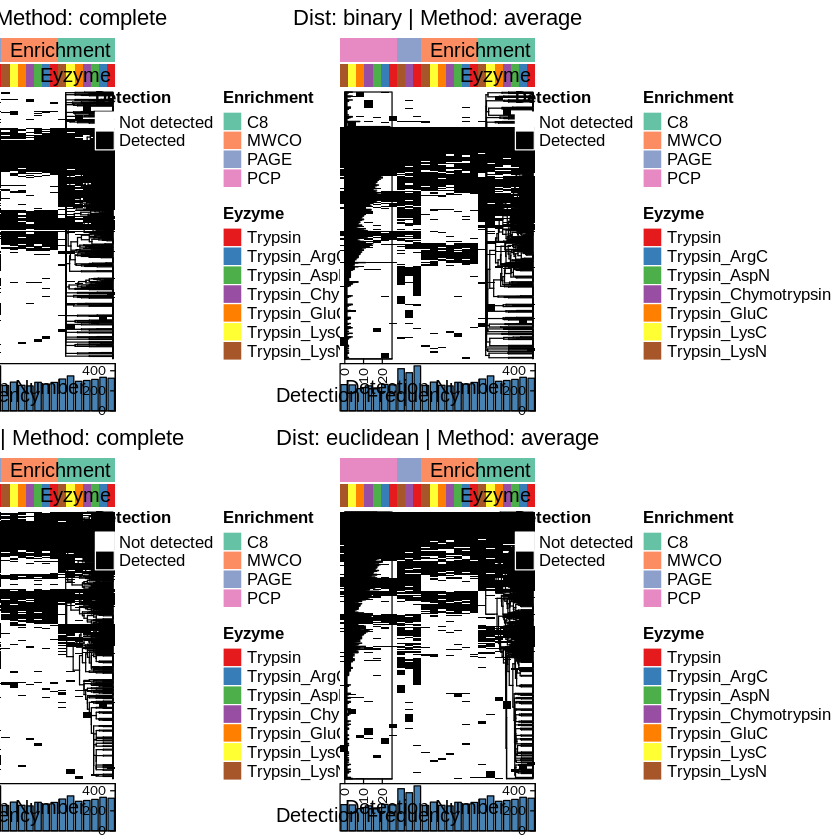

In [193]:
# 使用 grid.arrange 组合所有 grob
final_plot <- grid.arrange(grobs = grob_list, nrow = 2, ncol = 2)
# print(final_plot)
pdf("heatmap_comparison.pdf", width = 30, height = 10, onefile = TRUE)
grid.draw(final_plot)
dev.off()

# 手动对蛋白进行一些分类

In [27]:
all_sample_sep_m_meta_cano_1 %>% head()

,Protein,Sample,Eyzyme,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,sp|P60468|SC61B_HUMAN,21pcw_C8_T_T,Trypsin,C8
2,sp|P02656|APOC3_HUMAN,21pcw_C8_T_T,Trypsin,C8
3,sp|P52435|RPB11_HUMAN,21pcw_C8_T_T,Trypsin,C8
4,sp|Q96DA6|TIM14_HUMAN,21pcw_C8_T_T,Trypsin,C8
5,sp|P27816-7|MAP4_HUMAN,21pcw_C8_T_T,Trypsin,C8
6,sp|Q9H492|MLP3A_HUMAN,21pcw_C8_T_T,Trypsin,C8


In [28]:
protein_stats <- all_sample_sep_m_meta_cano_1 %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", "),  # 支持的富集方法（去重后逗号分隔）
  ) %>%
  arrange(desc(Unique_Methods), desc(Total_Observations),Supported_Enrichments)    # 排序逻辑不变

In [29]:
protein_stats %>% head()

Protein,Unique_Methods,Total_Observations,Supported_Enrichments
<chr>,<int>,<int>,<chr>
sp|C9JLW8|MCRI1_HUMAN,4,24,"C8, MWCO, PAGE, PCP"
sp|O00244|ATOX1_HUMAN,4,24,"C8, MWCO, PAGE, PCP"
sp|O43169|CYB5B_HUMAN,4,24,"C8, MWCO, PAGE, PCP"
sp|O75368|SH3L1_HUMAN,4,24,"C8, MWCO, PAGE, PCP"
sp|O75380|NDUS6_HUMAN,4,24,"C8, MWCO, PAGE, PCP"
sp|O75531|BAF_HUMAN,4,24,"C8, MWCO, PAGE, PCP"


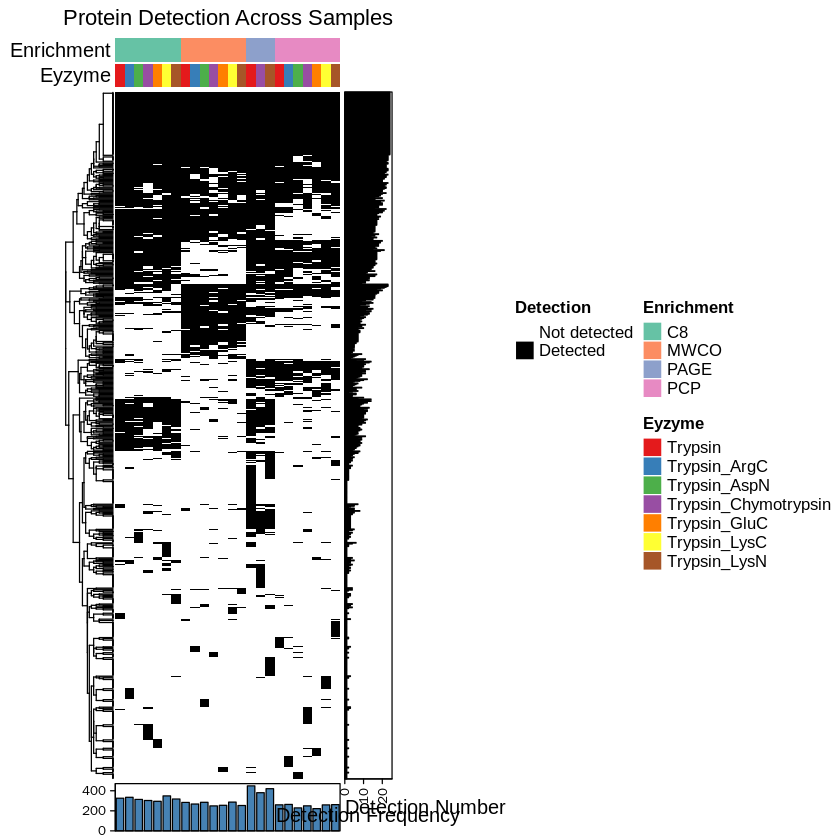

In [30]:

binary_matrix[protein_stats$Protein,] -> binary_matrix_1

# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix_1)
detection_number <- colSums(binary_matrix_1)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Eyzyme) %>%
  distinct() %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)


ht_1 <- Heatmap(
  binary_matrix_1,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)


draw(ht_1)

In [31]:
column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment)  # 强制分组顺序为 A → B
)
column_split

[1] C8   C8   C8   C8   C8   C8   C8   MWCO MWCO MWCO MWCO MWCO MWCO MWCO PAGE
[16] PAGE PAGE PCP  PCP  PCP  PCP  PCP  PCP  PCP 
Levels: C8 MWCO PAGE PCP

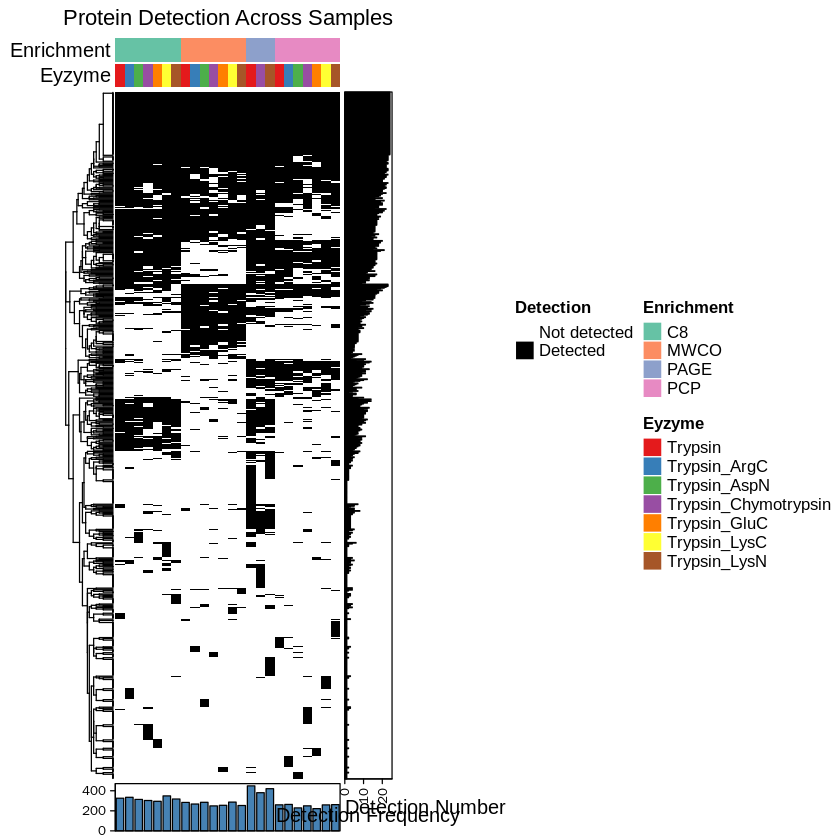

In [32]:
Heatmap(
  binary_matrix_1,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)

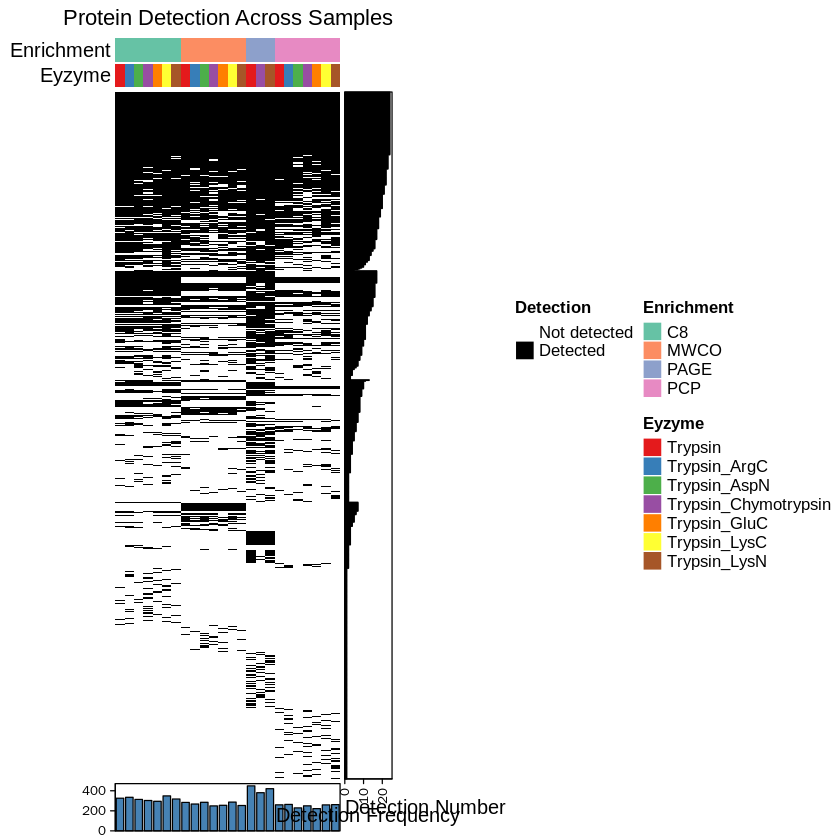

In [33]:
Heatmap(
  binary_matrix_1,
  name = "Detection",
  col = c("white", "black"),
  cluster_columns = FALSE,
  cluster_rows = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  column_title = "Protein Detection Across Samples",
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
)

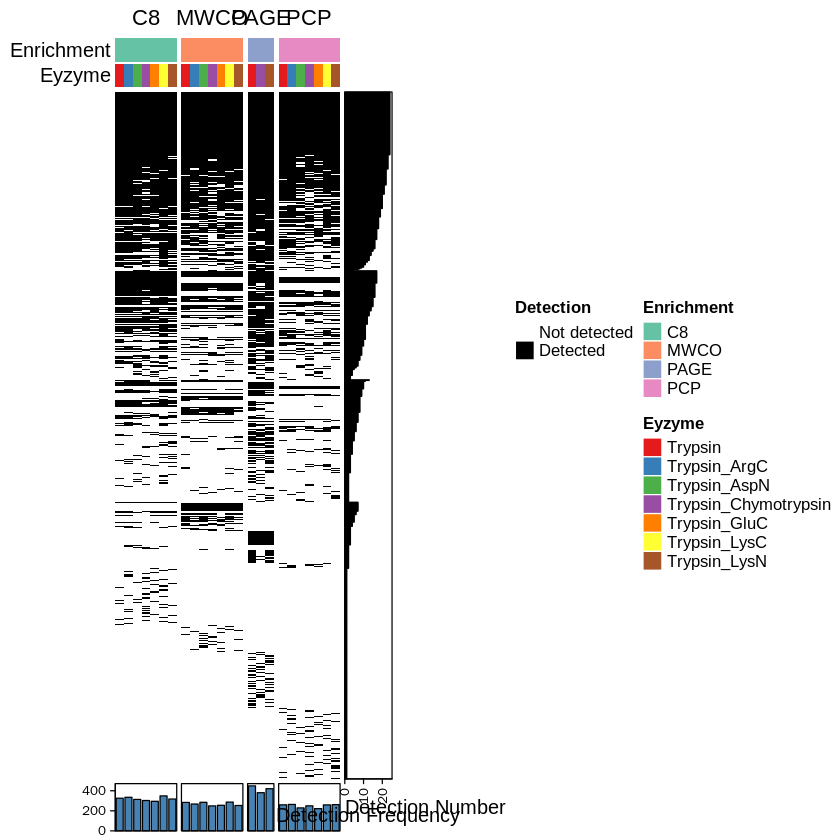

In [34]:
Heatmap(
  binary_matrix_1,
  name = "Detection",
  col = c("white", "black"),
    column_split = column_split,  # 分组向量
  column_title = levels(factor(column_split)),  # 分组标题
  cluster_columns = FALSE,
  cluster_rows = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = col_ha,
  right_annotation = row_ha,
  bottom_annotation = col_ha_1,
  heatmap_legend_param = list(
    at = c(0, 1),
    labels = c("Not detected", "Detected")
  ),
  use_raster=FALSE
) 

# 合并

In [10]:
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    distinct(df,Protein,Sample_merge_replicate,Eyzyme,Enrichment) -> df_1
    df_1 %>% rename(Sample=Sample_merge_replicate) -> df_2
    return(df_2)
}

In [5]:
heatmap_before_merge <- function(df){
    library(ComplexHeatmap)
    library(circlize)
    # Assuming your data is in a dataframe called all_sample_sep_m_meta
    # Create a binary detection matrix
    binary_matrix <- df %>%
      mutate(present = 1) %>%
      select(Sample, Protein, present) %>%
      pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
      column_to_rownames("Protein") %>%
      as.matrix()

    # Calculate detection frequency for each protein
    detection_freq <- rowSums(binary_matrix)
    detection_number <- colSums(binary_matrix)

    # Get unique sample annotations
    sample_annot <- df %>%
      select(Sample,Enrichment,Eyzyme,Replicate) %>%
      distinct() %>%
      mutate(Replicate = as.factor(Replicate)) %>%
      column_to_rownames("Sample")

    # Define colors for annotations
    enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                              unique(sample_annot$Eyzyme))
    enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                                  unique(sample_annot$Enrichment))
    replicate_colors <- setNames(brewer.pal(length(unique(sample_annot$Replicate)), "Set3"), 
                                 unique(sample_annot$Replicate))

    # Create column annotations
    col_ha <- HeatmapAnnotation(
      df = sample_annot,
      col = list(
        Eyzyme = enzyme_colors,
        Enrichment = enrichment_colors,
        Replicate = replicate_colors
      ),
      annotation_name_side = "left"
    )

    # Create row annotation for detection frequency
    row_ha <- rowAnnotation(
      "Detection Frequency" = anno_barplot(detection_freq, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )
    col_ha_1 <- columnAnnotation(
      "Detection Number" = anno_barplot(detection_number, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )


    ht_1 <- Heatmap(
      binary_matrix,
      name = "Detection",
      col = c("white", "black"),
      cluster_columns = FALSE,
      cluster_rows = TRUE,
      show_row_names = FALSE,
      show_column_names = FALSE,
      top_annotation = col_ha,
      right_annotation = row_ha,
      bottom_annotation = col_ha_1,
      column_title = "Protein Detection Across Samples",
      heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
      ),
      use_raster=FALSE
    )
    return(ht_1)
}

载入需要的程辑包：grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



载入程辑包：‘ComplexHeatmap’


The following 

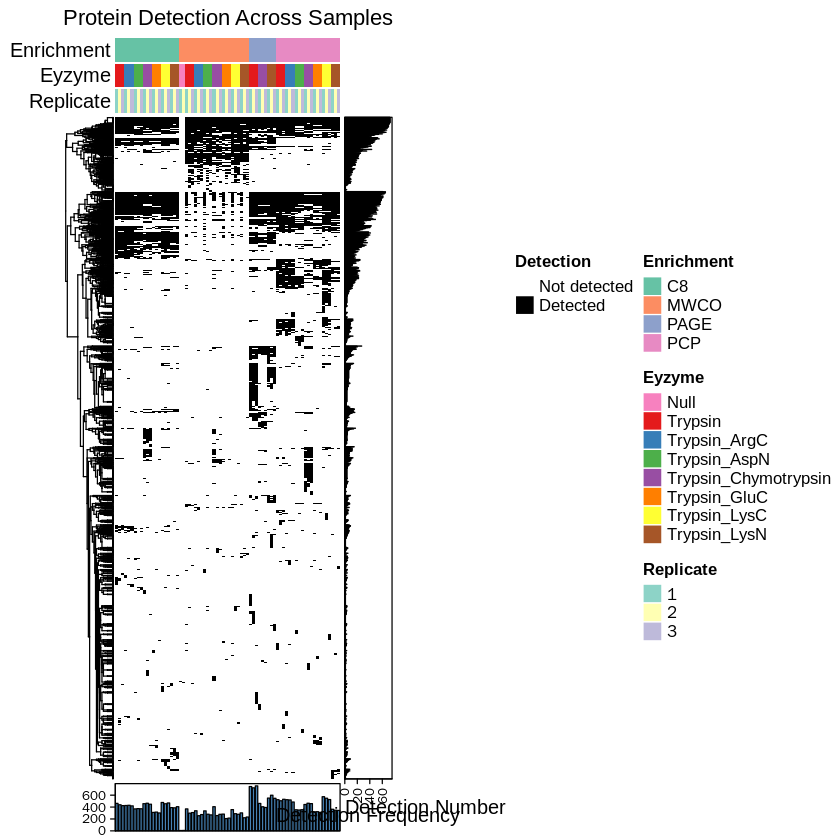

In [6]:
heatmap_before_merge(all_sample_sep_m_meta)

In [8]:
heatmap_after_merge <- function(df){
    library(ComplexHeatmap)
    library(circlize)
    # Assuming your data is in a dataframe called all_sample_sep_m_meta
    # Create a binary detection matrix
    binary_matrix <- df %>%
      mutate(present = 1) %>%
      select(Sample, Protein, present) %>%
      pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
      column_to_rownames("Protein") %>%
      as.matrix()

    # Calculate detection frequency for each protein
    detection_freq <- rowSums(binary_matrix)
    detection_number <- colSums(binary_matrix)

    # Get unique sample annotations
    sample_annot <- df %>%
      select(Sample,Enrichment,Eyzyme) %>%
      distinct() %>%
      column_to_rownames("Sample")

    # Define colors for annotations
    enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                              unique(sample_annot$Eyzyme))
    enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                                  unique(sample_annot$Enrichment))
    # Create column annotations
    col_ha <- HeatmapAnnotation(
      df = sample_annot,
      col = list(
        Eyzyme = enzyme_colors,
        Enrichment = enrichment_colors
      ),
      annotation_name_side = "left"
    )

    # Create row annotation for detection frequency
    row_ha <- rowAnnotation(
      "Detection Frequency" = anno_barplot(detection_freq, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )
    col_ha_1 <- columnAnnotation(
      "Detection Number" = anno_barplot(detection_number, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )


    ht_1 <- Heatmap(
      binary_matrix,
      name = "Detection",
      col = c("white", "black"),
      cluster_columns = FALSE,
      cluster_rows = TRUE,
      show_row_names = FALSE,
      show_column_names = FALSE,
      top_annotation = col_ha,
      right_annotation = row_ha,
      bottom_annotation = col_ha_1,
      column_title = "Protein Detection Across Samples",
      heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
      ),
      use_raster=FALSE
    )
    return(ht_1)
}

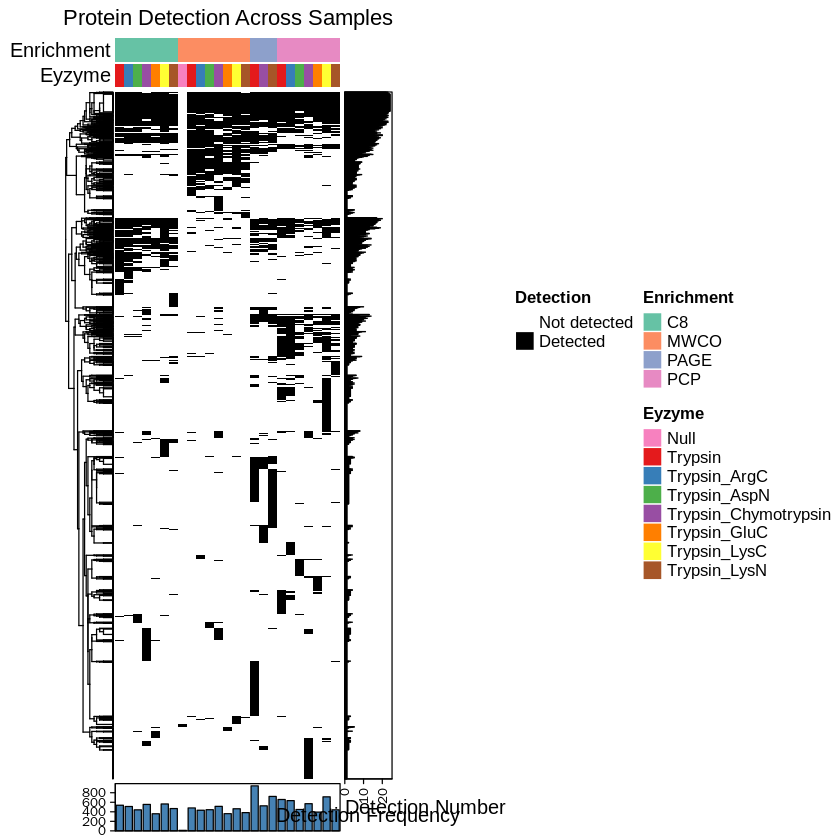

In [11]:
heatmap_after_merge(merge_replicate(all_sample_sep_m_meta))

In [ ]:
heatmap_after_merge_split_col_row

In [118]:
df <- merge_replicate(all_sample_sep_m_meta)

In [13]:
head(df)

,Protein,Sample,Eyzyme,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,sp|P60468|SC61B_HUMAN,21pcw_C8_T_T,Trypsin,C8
2,sp|P02656|APOC3_HUMAN,21pcw_C8_T_T,Trypsin,C8
3,sp|P52435|RPB11_HUMAN,21pcw_C8_T_T,Trypsin,C8
4,sp|Q96DA6|TIM14_HUMAN,21pcw_C8_T_T,Trypsin,C8
5,sp|P27816-7|MAP4_HUMAN,21pcw_C8_T_T,Trypsin,C8
6,sp|Q9H492|MLP3A_HUMAN,21pcw_C8_T_T,Trypsin,C8


In [119]:
define_type <- function(x){
    return(if_else(grepl("^sp",x),"Cano","Uncano"))
}
protein_stats <- df %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", ")  # 支持的富集方法（去重后逗号分隔）
  )
protein_stats$Unique_Methods <- as.character(protein_stats$Unique_Methods)
protein_stats$Type <- factor(define_type(protein_stats$Protein),levels = c("Cano","Uncano"))
# protein_stats %>% arrange(Type,desc(Unique_Methods), desc(Total_Observations),Supported_Enrichments) -> protein_stats
protein_stats %>% arrange(Type,desc(Unique_Methods), Supported_Enrichments,desc(Total_Observations)) -> protein_stats

In [120]:
protein_stats$Unique_Methods <- factor(protein_stats$Unique_Methods,levels=c('4','3','2','1'))

In [121]:
count(protein_stats,Supported_Enrichments)

Supported_Enrichments,n
<chr>,<int>
C8,402
"C8, MWCO",56
"C8, MWCO, PAGE",53
"C8, MWCO, PAGE, PCP",255
"C8, MWCO, PCP",78
"C8, PAGE",83
"C8, PAGE, PCP",92
"C8, PCP",94
MWCO,315


In [122]:

    library(ComplexHeatmap)
    library(circlize)
    # Assuming your data is in a dataframe called all_sample_sep_m_meta
    # Create a binary detection matrix
    binary_matrix_tmp <- df %>%
      mutate(present = 1) %>%
      select(Sample, Protein, present) %>%
      pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
      column_to_rownames("Protein") %>%
      as.matrix()
    # 按照特定顺序排序
    binary_matrix_tmp[protein_stats$Protein,] -> binary_matrix
    # Calculate detection frequency for each protein
    detection_freq <- rowSums(binary_matrix)
    detection_number <- colSums(binary_matrix)

    # Get unique sample annotations
    sample_annot <- df %>%
      select(Sample,Enrichment,Eyzyme) %>%
      distinct() %>%
      column_to_rownames("Sample")

    # Define colors for annotations
    enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                              unique(sample_annot$Eyzyme))
    enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                                  unique(sample_annot$Enrichment))
    # Create column annotations
    col_ha <- HeatmapAnnotation(
      df = sample_annot,
      col = list(
        Eyzyme = enzyme_colors,
        Enrichment = enrichment_colors
      ),
      annotation_name_side = "left"
    )

    # Create row annotation for detection frequency
    row_ha <- rowAnnotation(
      "Detection Frequency" = anno_barplot(detection_freq, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )
    col_ha_1 <- columnAnnotation(
      "Detection Number" = anno_barplot(detection_number, 
                                           bar_width = 0.8,
                                           gp = gpar(fill = "steelblue",col=NULL))
    )





In [123]:
column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment) 
)
column_split

[1] C8   C8   C8   C8   C8   C8   C8   MWCO MWCO MWCO MWCO MWCO MWCO MWCO MWCO
[16] PAGE PAGE PAGE PCP  PCP  PCP  PCP  PCP  PCP  PCP 
Levels: C8 MWCO PAGE PCP

In [124]:
groups <- paste0(protein_stats$Type,"-",protein_stats$Unique_Methods)
row_split <- factor(
    groups, 
    levels = unique(groups)
)

In [125]:
# Define colors for annotations
type_colors <- setNames(brewer.pal(length(unique(protein_stats$Type)), "Set1"), 
                          unique(protein_stats$Type))
method_colors <- setNames(brewer.pal(length(unique(protein_stats$Unique_Methods)), "Set2"), 
                              unique(protein_stats$Unique_Methods))
protein_stats[,c("Type","Unique_Methods")]  %>% as.data.frame() -> row_anno
rownames(row_anno) <- protein_stats$Protein
# Create column annotations
row_ha_1 <- rowAnnotation(
  df = row_anno,
  col = list(
    Type = type_colors[1:2],
    Unique_Methods = method_colors
  ),
  annotation_name_side = "bottom"
)

Warning message in brewer.pal(length(unique(protein_stats$Type)), "Set1"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


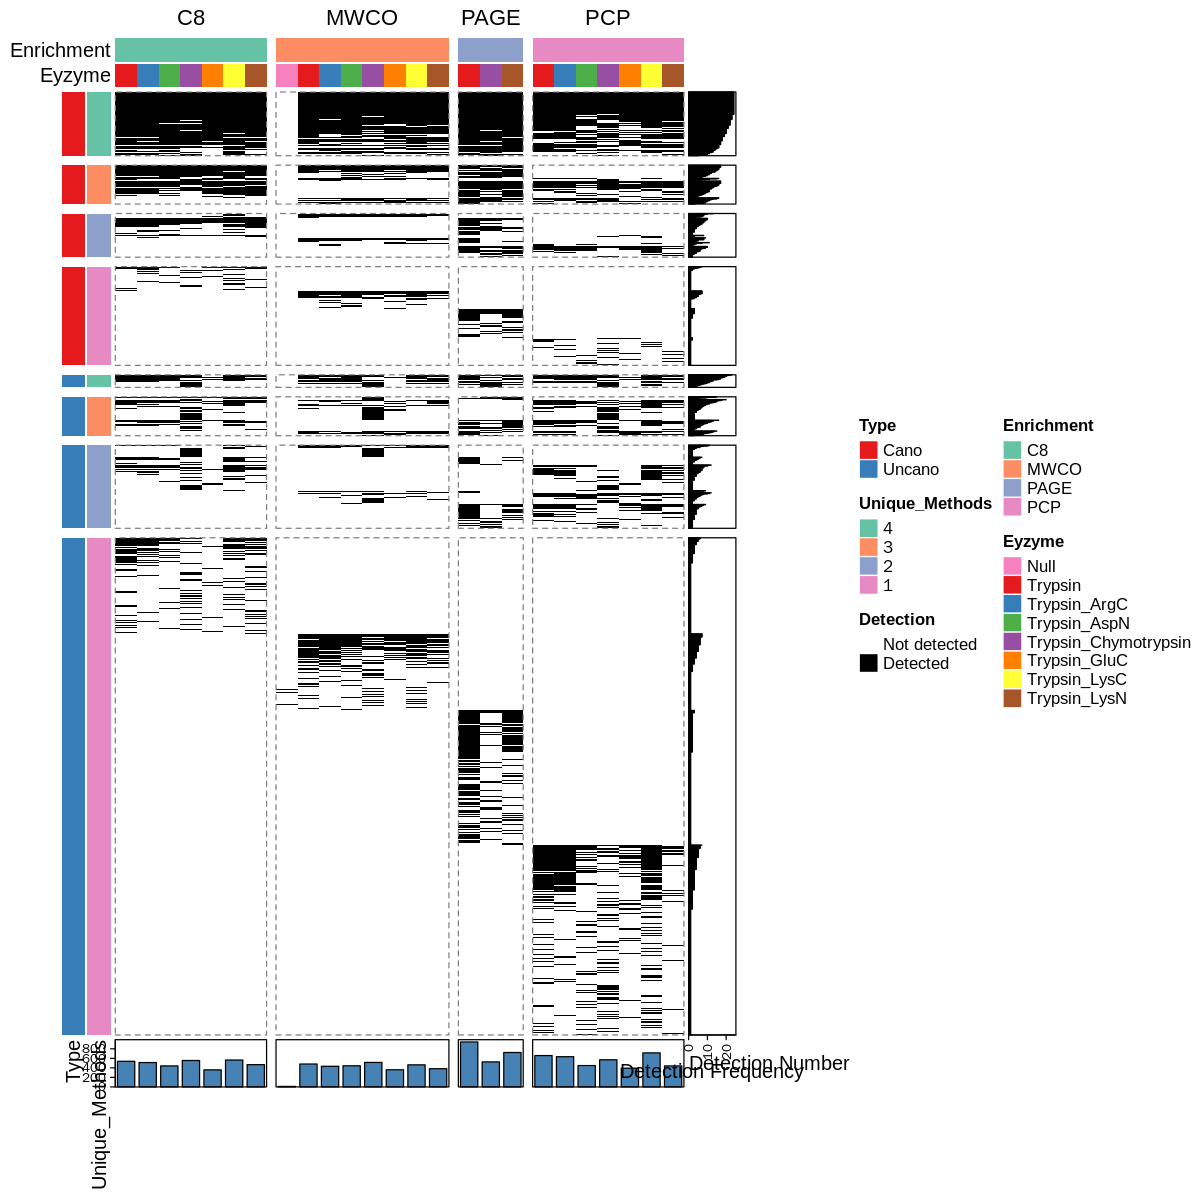

In [129]:
options(repr.plot.width = 10, repr.plot.height = 10)
ht_1 <- Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = FALSE,
    cluster_rows = FALSE,
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
#     column_title = levels(factor(column_split)),
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    use_raster = FALSE,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)
ht_1